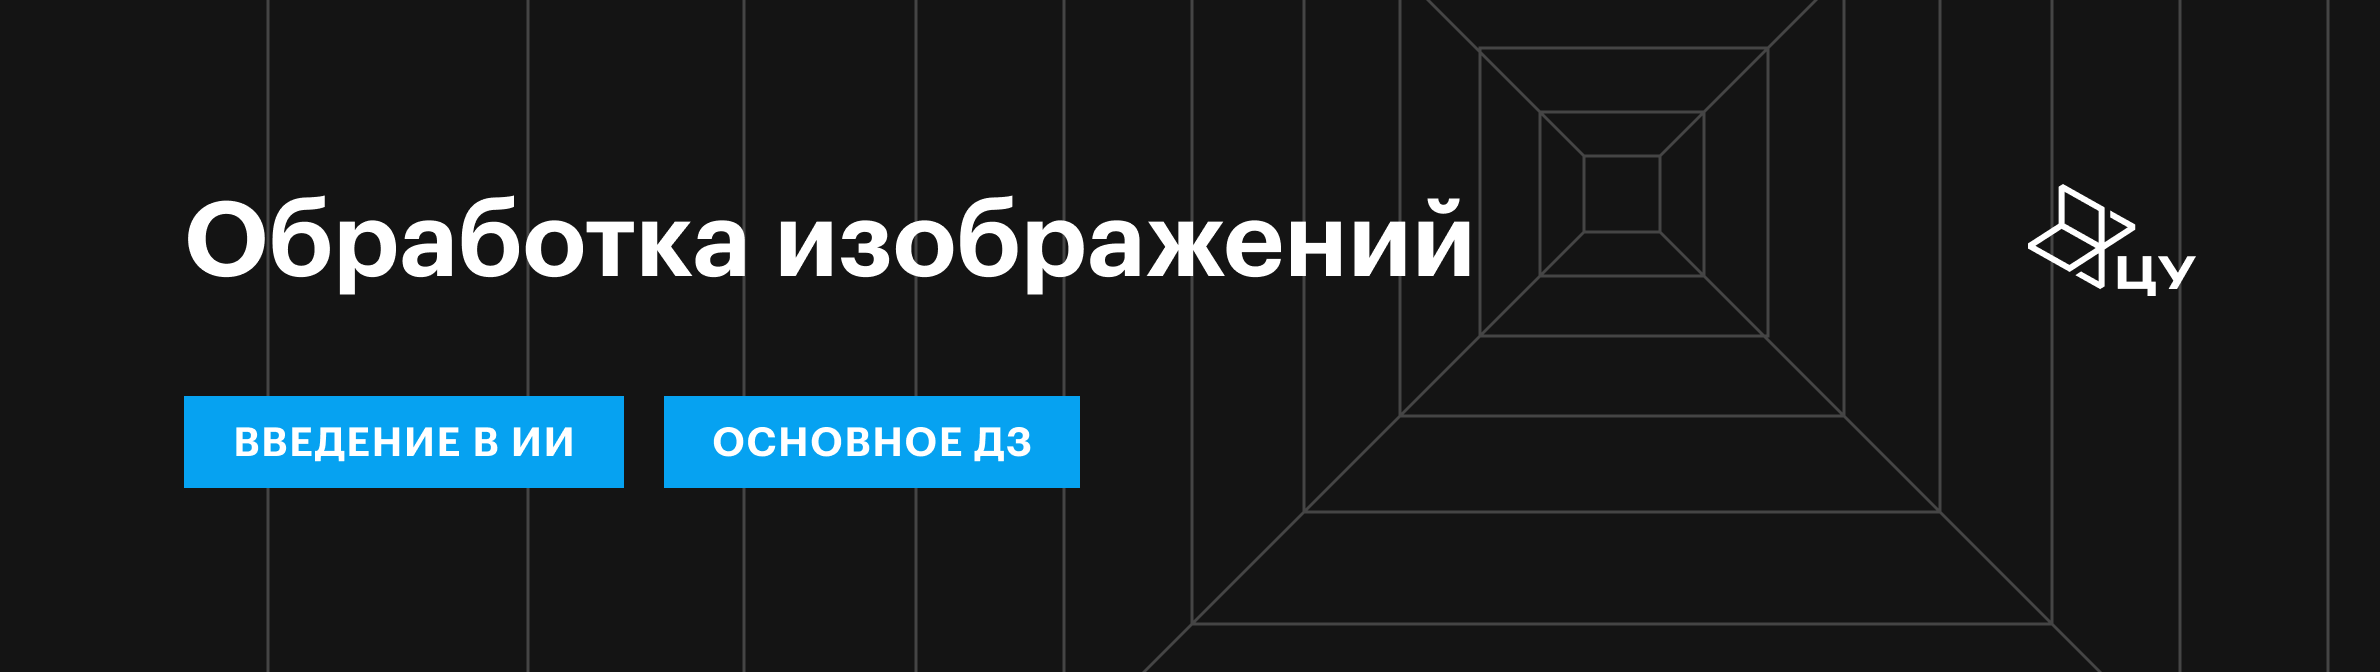

# Домашнее задание по теме «Обработка изображений»

Цель этого домашнего задания — разобраться, как изображение можно представить в виде признаков, какие ограничения у этого подхода и почему классические модели не всегда хорошо справляются с задачей.

Тебе нужно будет показать логику рассуждений: что хранит то или иное представление изображения, какая информация при этом теряется и как это влияет на качество модели.

> ### Правила домашнего задания
> 1. Нельзя удалять существующие ячейки кода.
> 2. Можно добавлять и дописывать свои ячейки.
> 3. Место, куда тебе нужно написать код, помечается комментарием.
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
> 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.
> 7. В этом домашнем задании особенно важно пояснять, какие данные модель видит в признаках и какие закономерности может обнаружить.

## Описание задачи

Тебе нужно собрать прототип для распознавания изображений, используя простые признаки и классические модели. А также определить, в какой момент такой подход перестаёт работать.

## Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.datasets import load_sample_image, load_digits
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

np.random.seed(42)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["image.cmap"] = "gray"


Чтобы код запускался без скачиваний и дополнительной настройки, используй только встроенные данные из sklearn:

- `flower.jpg` — реальное цветное изображение для задач на яркость, преобразования и гистограммы;
- `digits` — маленький датасет изображений рукописных цифр размера `8 × 8` для задач на признаки и классификацию.

In [2]:
def rgb_to_gray(img):
    """Перевод RGB-изображения в оттенки серого по стандартной взвешенной формуле."""
    gray = 0.299 * img[..., 0] + 0.587 * img[..., 1] + 0.114 * img[..., 2]
    return np.clip(gray, 0, 255).astype(np.uint8)

def hist_features(images, bins=16, value_range=(0.0, 1.0)):
    """Строит нормированные гистограммные признаки для набора изображений."""
    features = []
    for img in images:
        hist, _ = np.histogram(img, bins=bins, range=value_range)
        hist = hist.astype(np.float32)
        hist = hist / hist.sum()
        features.append(hist)
    return np.array(features)

def shift_right_batch(images, shift=1):
    """Сдвигает батч изображений вправо с заполнением нулями."""
    shifted = np.zeros_like(images)
    shifted[:, :, shift:] = images[:, :, :-shift]
    return shifted

def make_same_hist_patterns(size=32, seed=42):
    """Создаёт несколько разных бинарных изображений с одинаковой гистограммой."""
    left_right = np.zeros((size, size), dtype=np.uint8)
    left_right[:, size // 2:] = 255

    checkerboard = ((np.indices((size, size)).sum(axis=0) % 2) * 255).astype(np.uint8)

    shuffled = left_right.ravel().copy()
    rng = np.random.default_rng(seed)
    rng.shuffle(shuffled)
    shuffled = shuffled.reshape(size, size)

    return left_right, checkerboard, shuffled

def describe_gray_image(img):
    return {
        "mean": float(img.mean()),
        "std": float(img.std()),
        "min": int(img.min()),
        "max": int(img.max()),
    }

flower = load_sample_image("flower.jpg")
flower_gray = rgb_to_gray(flower)
digits = load_digits()

print("flower:", flower.shape, flower.dtype)
print("flower_gray:", flower_gray.shape, flower_gray.dtype)
print("digits.images:", digits.images.shape)

flower: (427, 640, 3) uint8
flower_gray: (427, 640) uint8
digits.images: (1797, 8, 8)


## Задание 1. Одинаковая гистограмма — разные изображения [2,5 балла]


На лекции мы обсуждали, что гистограмма показывает распределение яркостей, но не хранит информацию о том, где именно находятся пиксели. Проверь это на простом примере.

[0.5 баллa] Создай три бинарных изображения размера `32 × 32`, состоящих только из значений `0` и `255`:

- левая половина чёрная, правая — белая;
- шахматка;
- первое изображение со случайно перестановленными пикселями.

1. [0.5 баллa] Затем отобрази все три изображения.
2. [0.5 баллa] Для каждого построй гистограмму.
3. [0.5 баллa] Проверь, совпадает ли количество чёрных и белых пикселей.
4. [0.5 баллa] Объясни, почему изображения визуально очень разные, хотя их гистограммы одинаковые.

>**Подсказка.** У всех трёх изображений должно быть поровну чёрных и белых пикселей.

In [3]:
f, s, t = make_same_hist_patterns(32)

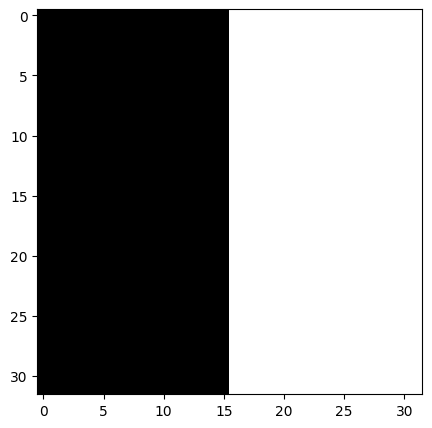

In [4]:
plt.imshow(f, cmap='gray', vmin=0, vmax=255)

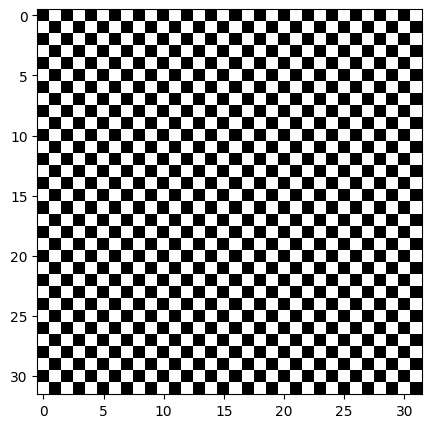

In [5]:
plt.imshow(s, cmap='gray', vmin=0, vmax=255)

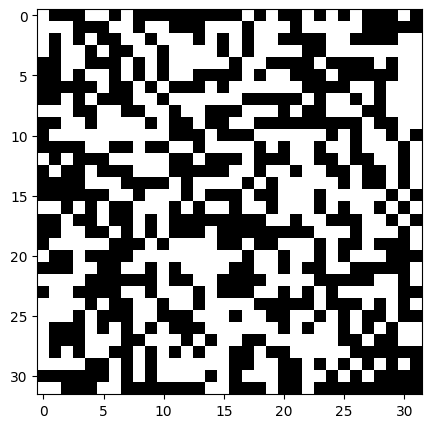

In [6]:
plt.imshow(t, cmap='gray', vmin=0, vmax=255)


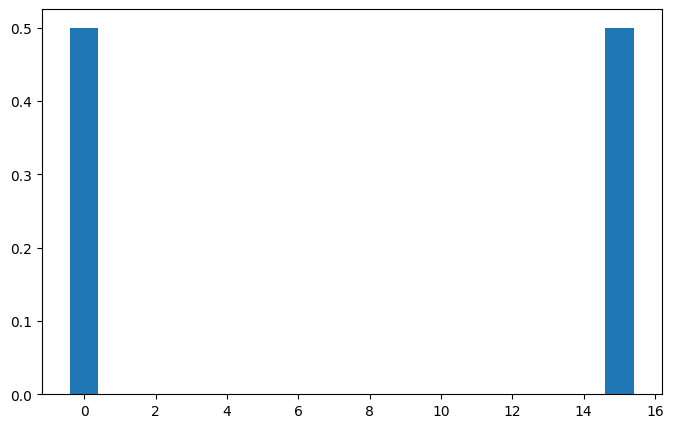

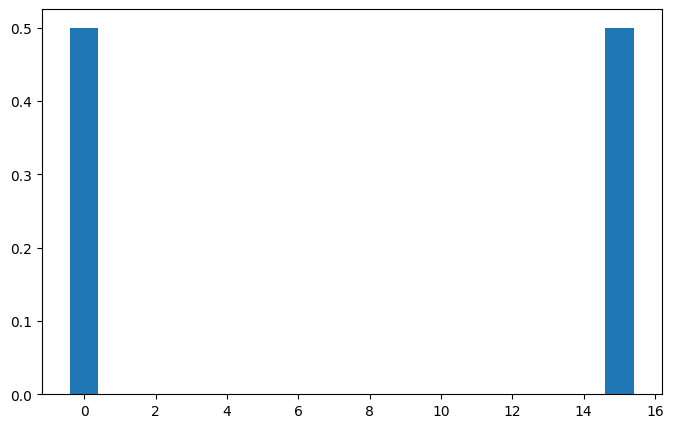

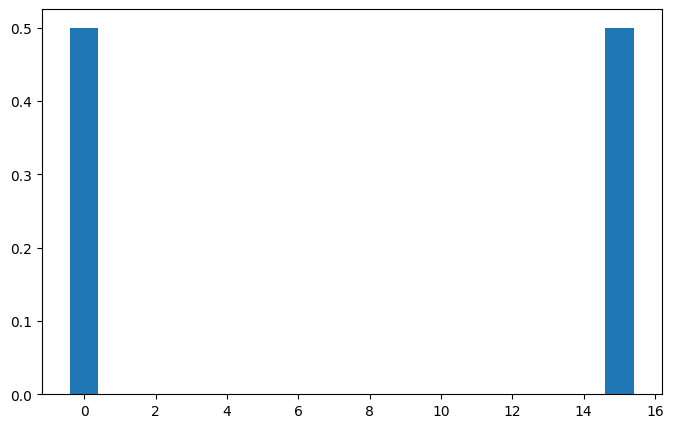

In [7]:
for hist in hist_features([f, s, t], value_range=(0, 255)):
    plt.bar(range(16), hist)
    plt.show()

Все совпадает, так как количество черных и белых пикселей во всех изображениях одинаково

Напиши выводы здесь.

## Задание 2. Как простые преобразования меняют глобальные признаки изображения [2,5 балла]


Теперь перейди к реальному изображению `flower.jpg`.

1. [0.4 баллa] Переведи изображение в оттенки серого.
2. [0.7 баллa] Построй четыре версии grayscale-изображения:
   - исходное;
   - горизонтальный флип;
   - более яркая версия (`+40` к яркости с обрезкой в диапазон `[0, 255]`);
   - версия с пониженным контрастом.
3. [0.7 баллa] Для каждой версии:
   - отобрази изображение;
   - построй гистограмму;
   - посчитай `mean`, `std`, `min`, `max`.
4. [0.7 баллa] Выясни, какие преобразования:
   - почти не меняют глобальное распределение яркостей,
   - заметно меняют распределение,
   - меняют структуру изображения без существенного изменения гистограммы.

>**Подсказка.** Пониженный контраст удобно делать как `new = mean + alpha * (img - mean)` при `alpha < 1`.

array([[13, 12, 15, ..., 52, 51, 51],
       [12, 12, 15, ..., 51, 51, 51],
       [11, 14, 15, ..., 51, 51, 51],
       ...,
       [31, 33, 32, ..., 30, 29, 30],
       [32, 33, 32, ..., 31, 30, 30],
       [32, 33, 31, ..., 32, 31, 31]], dtype=uint8)
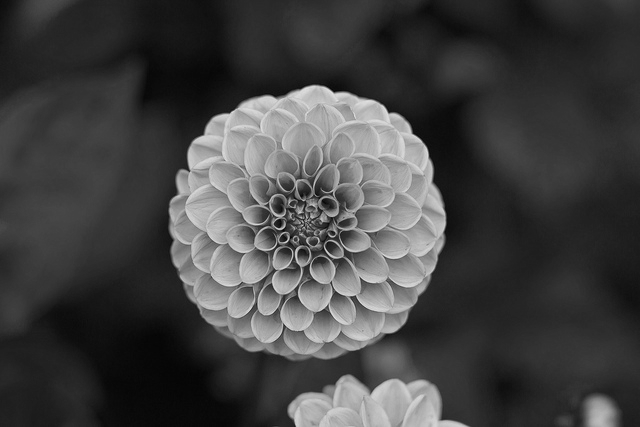

In [8]:
flower_gray


array([[51, 51, 52, ..., 15, 12, 13],
       [51, 51, 51, ..., 15, 12, 12],
       [51, 51, 51, ..., 15, 14, 11],
       ...,
       [30, 29, 30, ..., 32, 33, 31],
       [30, 30, 31, ..., 32, 33, 32],
       [31, 31, 32, ..., 31, 33, 32]], dtype=uint8)
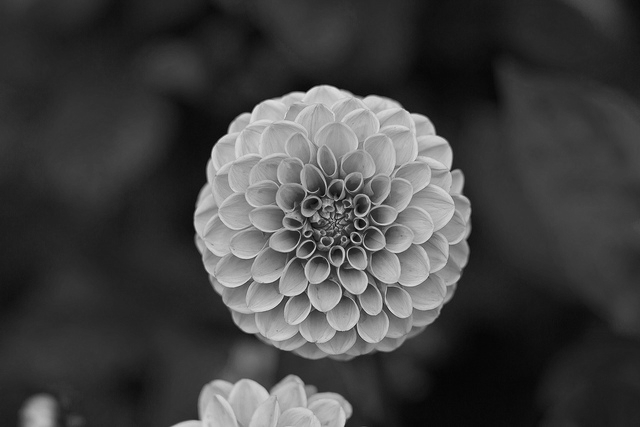

In [9]:
flip_flower_gray = flower_gray[:,::-1]
flip_flower_gray

array([[53, 52, 55, ..., 92, 91, 91],
       [52, 52, 55, ..., 91, 91, 91],
       [51, 54, 55, ..., 91, 91, 91],
       ...,
       [71, 73, 72, ..., 70, 69, 70],
       [72, 73, 72, ..., 71, 70, 70],
       [72, 73, 71, ..., 72, 71, 71]], dtype=uint8)
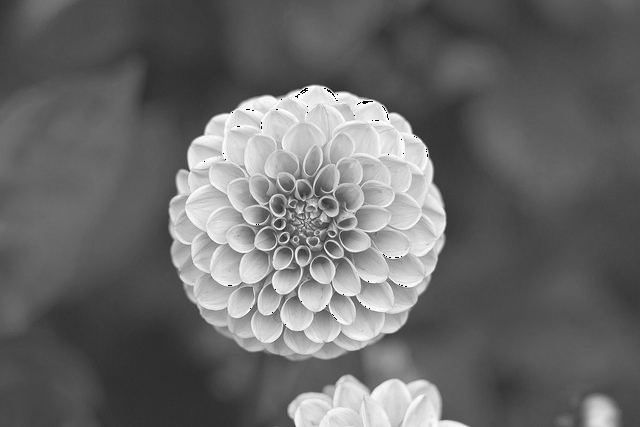

In [10]:
bright_flower_gray = flower_gray + 40
bright_flower_gray = np.clip(bright_flower_gray, 0, 255)
bright_flower_gray

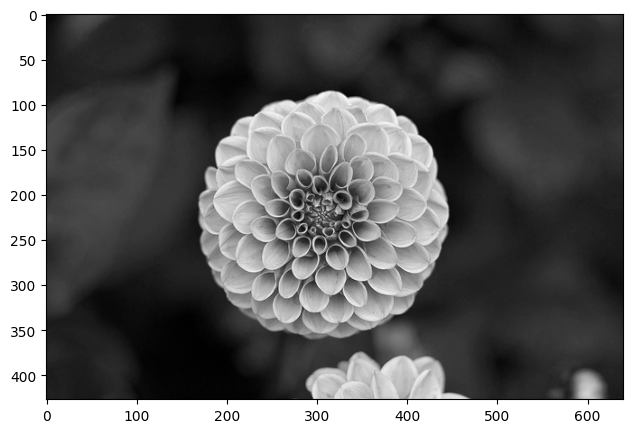

In [11]:
lower_flower_gray = flower_gray.mean() + 0.5 * (flower_gray - flower_gray.mean())
plt.imshow(lower_flower_gray, cmap='gray')

In [12]:
for k in [flower_gray, flip_flower_gray, bright_flower_gray, lower_flower_gray]:
  print(describe_gray_image(k))

{'mean': 65.70034396955504, 'std': 52.77446771130804, 'min': 5, 'max': 227}
{'mean': 65.70034396955504, 'std': 52.774467711308056, 'min': 5, 'max': 227}
{'mean': 105.55327137002342, 'std': 52.707140237437564, 'min': 0, 'max': 255}
{'mean': 65.70034396955502, 'std': 26.387233855654024, 'min': 35, 'max': 146}


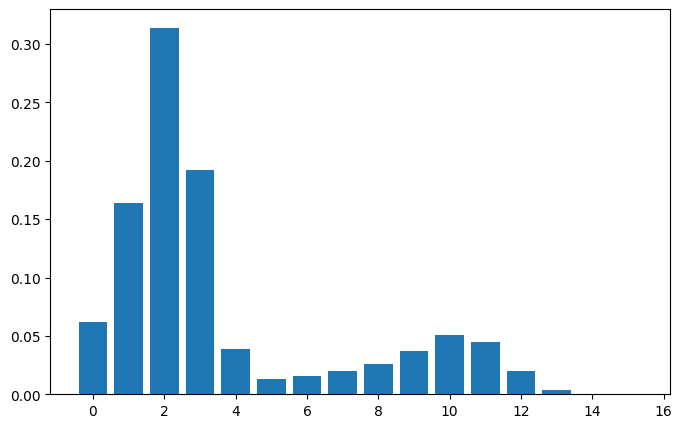

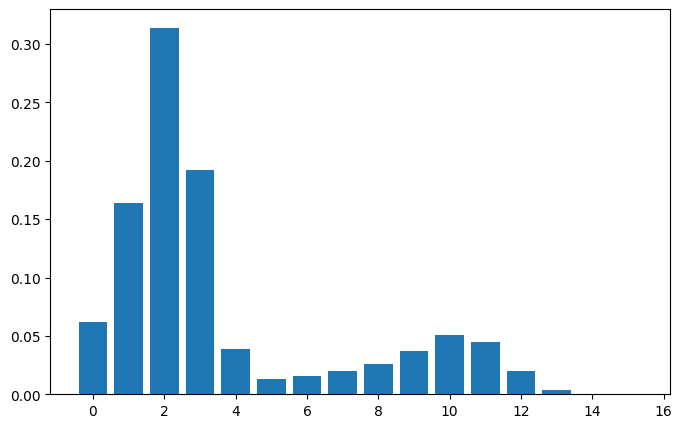

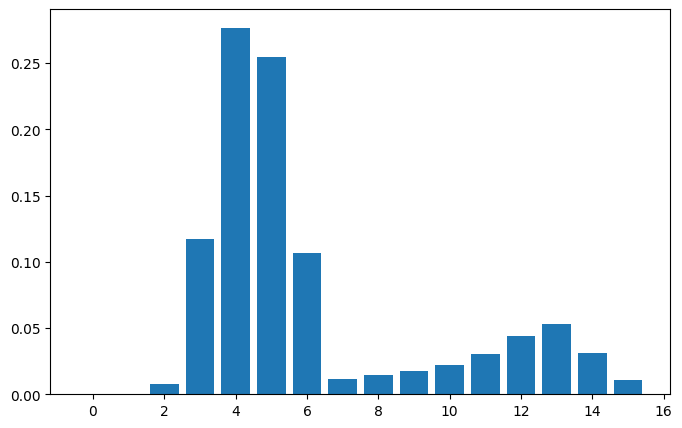

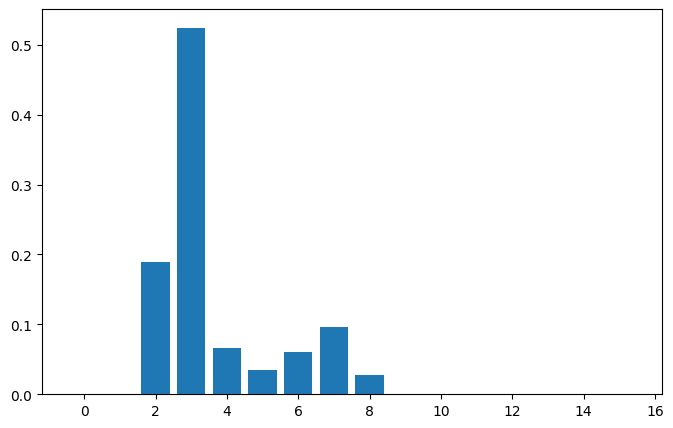

In [13]:
for hist in hist_features([flower_gray, flip_flower_gray, bright_flower_gray, lower_flower_gray], value_range=(0, 255)):
    plt.bar(range(16), hist)
    plt.show()

Напиши выводы здесь.

## Задание 3. Два способа описать изображение цифры [2,5 балла]

Теперь возьми датасет `digits` и оставь только цифры `3` и `8`.

Подготовь два разных представления одного и того же изображения.

1. `flatten`-представление — разверни изображение `8 × 8` в вектор длины `64`.
2. Гистограммное представление — построй по изображению нормированную гистограмму яркости из `16` бинов.

Выполни следующие шаги.

1. [0.2 баллa] Отбери только классы `3` и `8`.
2. [0.3 баллa] Нормируй значения пикселей в диапазон от `0` до `1`.
3. [0.2 баллa] Покажи по три примера каждого класса.
4. [0.8 баллa]Построй матрицы признаков `X_flat` и `X_hist`.
5. Выведи их размеры.
6. [0.7 баллa] Построй:
   - среднее изображение для каждого класса,
   - среднюю гистограмму для каждого класса.
7. [0.8 баллa] Сравни два представления:
   - какое хранит пространственную структуру;
   - какое компактнее;
   - какое потенциально устойчивее к небольшим перестановкам пикселей.

>**Важно.** Здесь нельзя просто написать «`flatten` лучше» или «`hist` хуже». Нужно объяснить, какую именно информацию хранит каждое представление.

In [46]:
mask = ((digits.target == 3) | (digits.target == 8))
images = digits.images[mask] / 16.0
target = digits.target[mask]

In [16]:
data1 = data.reshape((357, 8, -1))

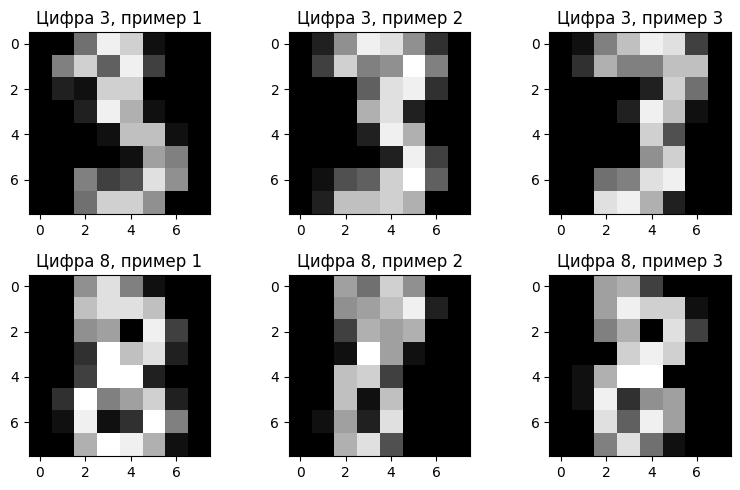

In [52]:
fig, axes = plt.subplots(2, 3)
for row, digit in enumerate([3, 8]):
    examples = images[target == digit][:3]
    for col in range(3):
        axes[row, col].imshow(examples[col])
        axes[row, col].set_title(f"Цифра {digit}, пример {col+1}")
plt.tight_layout()

In [53]:
X_flat = images.reshape(len(images), -1)
X_hist = hist_features(images)
y = target

print(X_flat.shape)
print(X_hist.shape)


(357, 64)
(357, 16)


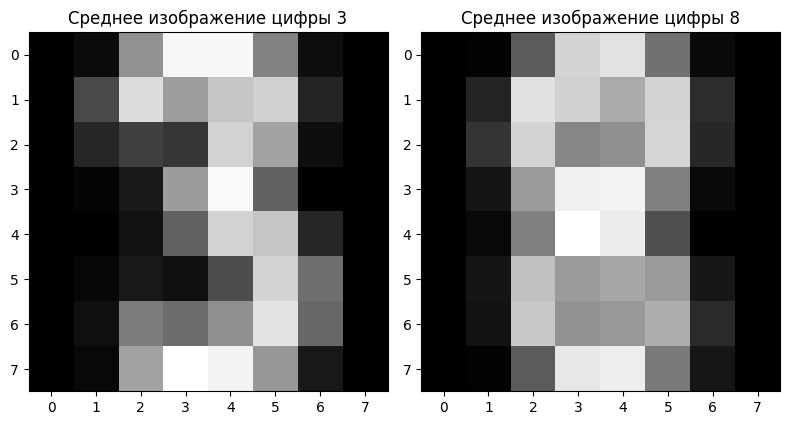

In [57]:
fig, axes = plt.subplots(1, 2)
for ax, digit in zip(axes, [3, 8]):
    ax.imshow(images[target == digit].mean(axis=0))
    ax.set_title(f"Среднее изображение цифры {digit}")
plt.tight_layout()


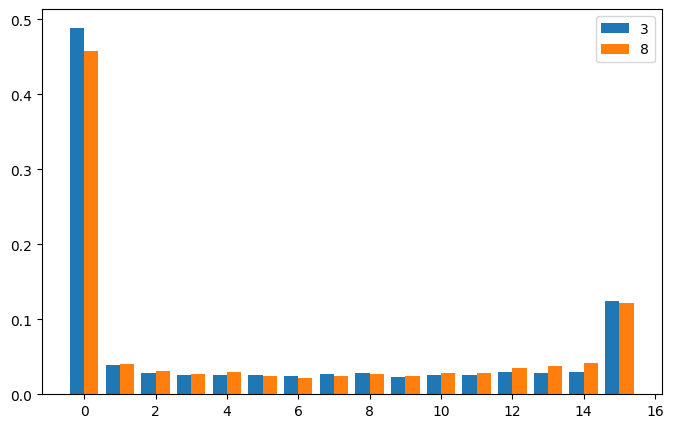

In [60]:
m3 = X_hist[y == 3].mean(axis=0)
m8 = X_hist[y == 8].mean(axis=0)

plt.bar(np.arange(16) - 0.2, m3, width=0.4, label="3")
plt.bar(np.arange(16) + 0.2, m8, width=0.4, label="8")
plt.legend()

Хранит пространственную структуру - флаттен представление, но hist компакнее, он использует в 4 раза меньше памяти, hist не почувствует смены положения пикселей, но небольшая смена пикселей на flat повлияет, так как все запоминается именно от расположения пикселей

Напиши выводы здесь.

## Задание 4. Логистическая регрессия на `flatten` и чувствительность к сдвигу [2,5 балла]


Обучи логистическую регрессию на признаках `flatten`.

Выполни следующие шаги.

1. [0.1 баллa] Разбей данные на train и test (`stratify=y`, `random_state=42`).
2. [0.4 баллa] Обучи `LogisticRegression` на `X_flat`.
3. [0.2 баллa] Посчитай accuracy на обычном тесте.
4. [0.3 баллa] Создай новую версию тестовых изображений: сдвинь каждую цифру вправо на 1 пиксель с заполнением нулями.
5. [0.2 баллa] Снова посчитай accuracy — уже на сдвинутом тесте.
6. [0.3 баллa] Построй `confusion matrix`:
   - для обычного теста,
   - для сдвинутого теста.
7. [0.1 баллa] Покажи несколько примеров ошибок на сдвинутом тесте.
8. [0.4 баллa] Обучи ещё одну `LogisticRegression` на `X_hist` и сравни её качество на обычном и сдвинутом тесте.

[0.5 баллa] После этого ответь на вопросы.

- Почему модель на `flatten` может хорошо работать на исходных изображениях?
- Почему даже маленький сдвиг ухудшает качество?
- Почему модель на гистограммах слабее на обычном тесте, но может быть менее чувствительной к такому сдвигу?



In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [30]:
X = (digits.data - digits.data.min()) / digits.data.max()
y = digits.target

In [72]:
X_train_flat, X_test_flat, y_train, y_test = train_test_split(X_flat, y, test_size=0.25, random_state=42, stratify=y)

X_train_hist, X_test_hist, _, _ = train_test_split(X_hist, y, test_size=0.25, random_state=42, stratify=y)


model_flat = LogisticRegression(max_iter=1000)
model_flat.fit(X_train_flat, y_train)
preds1 = model_flat.predict(X_test_flat)
acc1 = accuracy_score(y_test, preds1)
print(acc1)


0.9777777777777777


In [73]:
reshaped_X_test = X_test_flat.reshape((-1, 8, 8))
s_X_test_flat = shift_right_batch(reshaped_X_test).reshape(len(X_test_flat), -1)


In [74]:
preds2 = model_flat.predict(s_X_test_flat)
acc2 = accuracy_score(y_test, preds2)
print(acc2)

0.6555555555555556


In [65]:
print(confusion_matrix(y_test, preds1))
print(confusion_matrix(y_test, preds2))



[[44  2]
 [ 0 44]]
[[46  0]
 [31 13]]


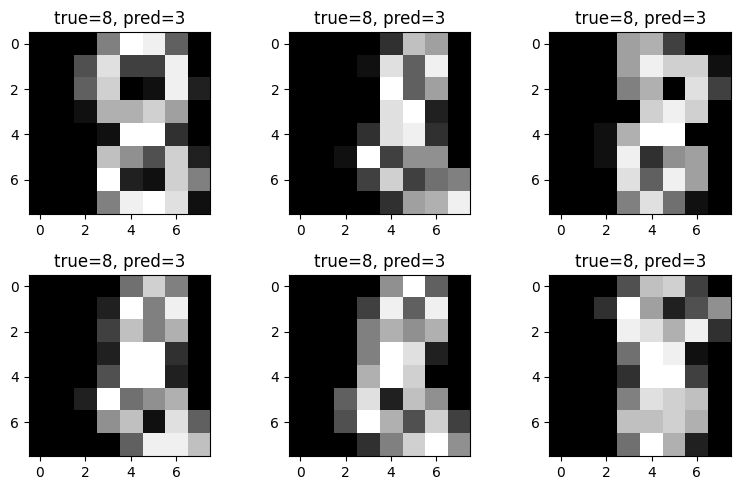

In [68]:
error_ids = np.where(preds2 != y_test)[0][:6]
fig, axes = plt.subplots(2, 3)
axes = axes.ravel()
for ax, idx in zip(axes, error_ids):
    ax.imshow(shifted_X_test_flat[idx].reshape(8, 8))
    ax.set_title(f"true={y_test[idx]}, pred={preds2[idx]}")
plt.tight_layout()

In [80]:
model_hist = LogisticRegression(max_iter=1000, random_state=42)
model_hist.fit(X_train_hist, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [81]:
preds3 = model_hist.predict(X_test_hist)
acc3 = accuracy_score(y_test, preds3)
print(acc3)

0.5888888888888889


In [83]:

s_X_test_hist = hist_features(shift_right_batch(reshaped_X_test))
preds4 = model_hist.predict(s_X_test_hist)
acc4 = accuracy_score(y_test, preds4)

results_df = pd.DataFrame(
    {
        "модель": ["flatten", "hist"],
        "обычный": [acc1, acc3],
        "сдвинутый": [acc2, acc4],
    }
)
display(results_df)

,модель,обычный,сдвинутый
0,flatten,0.977778,0.655556
1,hist,0.588889,0.588889


flatten видит каждый пиксель на своём месте и может выучить форму цифры, а hist просто запоминает распределение яркости. сдвиг на один пиксель переносит важные элементы в другие позиции, и признаки уже не совпадают с теми, на которых модель обучалась, поэтому качество заметно падает.
модель hist слабее на обычном тесте, потому что не знает, где расположен штрих, она видит только общий набор яркостей, из-за чего не чувствительна к сдвигу, т.к. сдвиг не меняет набор яркостей